# 04 - Time-Series Forecasting (ARIMA vs SARIMA)

CRED Market Entry and Segmentation Diagnostic - Shashank Tiwari, IIT Kharagpur

In [1]:
import sys, warnings, logging
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import config
from src.utils import setup_logging
setup_logging(logging.INFO)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
FIG = config.FIGURES_DIR

In [2]:
from src.time_series import build_cluster_series, evaluate_forecasts, summarise
clustered = pd.read_csv(config.CLUSTERED_FILE)
panel = pd.read_csv(config.RAW_PANEL_FILE)
series = build_cluster_series(clustered, panel)
(series / 1e6).round(2).tail(6)

04:52:54 | INFO    | cred.time_series | Built 7 monthly series x 24 months


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,Overall
timestamp_month,,,,,,,
2024-01-01,685.67,162.66,137.01,259.53,23.83,1527.23,2795.93
2024-02-01,839.66,198.54,166.64,321.73,29.10,1866.61,3422.28
2024-03-01,1062.44,250.70,210.29,406.16,36.72,2363.75,4330.08
2024-04-01,904.96,213.23,179.59,343.42,31.31,2004.88,3677.39
2024-05-01,869.16,205.39,172.56,332.86,30.05,1936.37,3546.39
2024-06-01,937.97,222.42,187.16,357.44,32.68,2089.91,3827.58


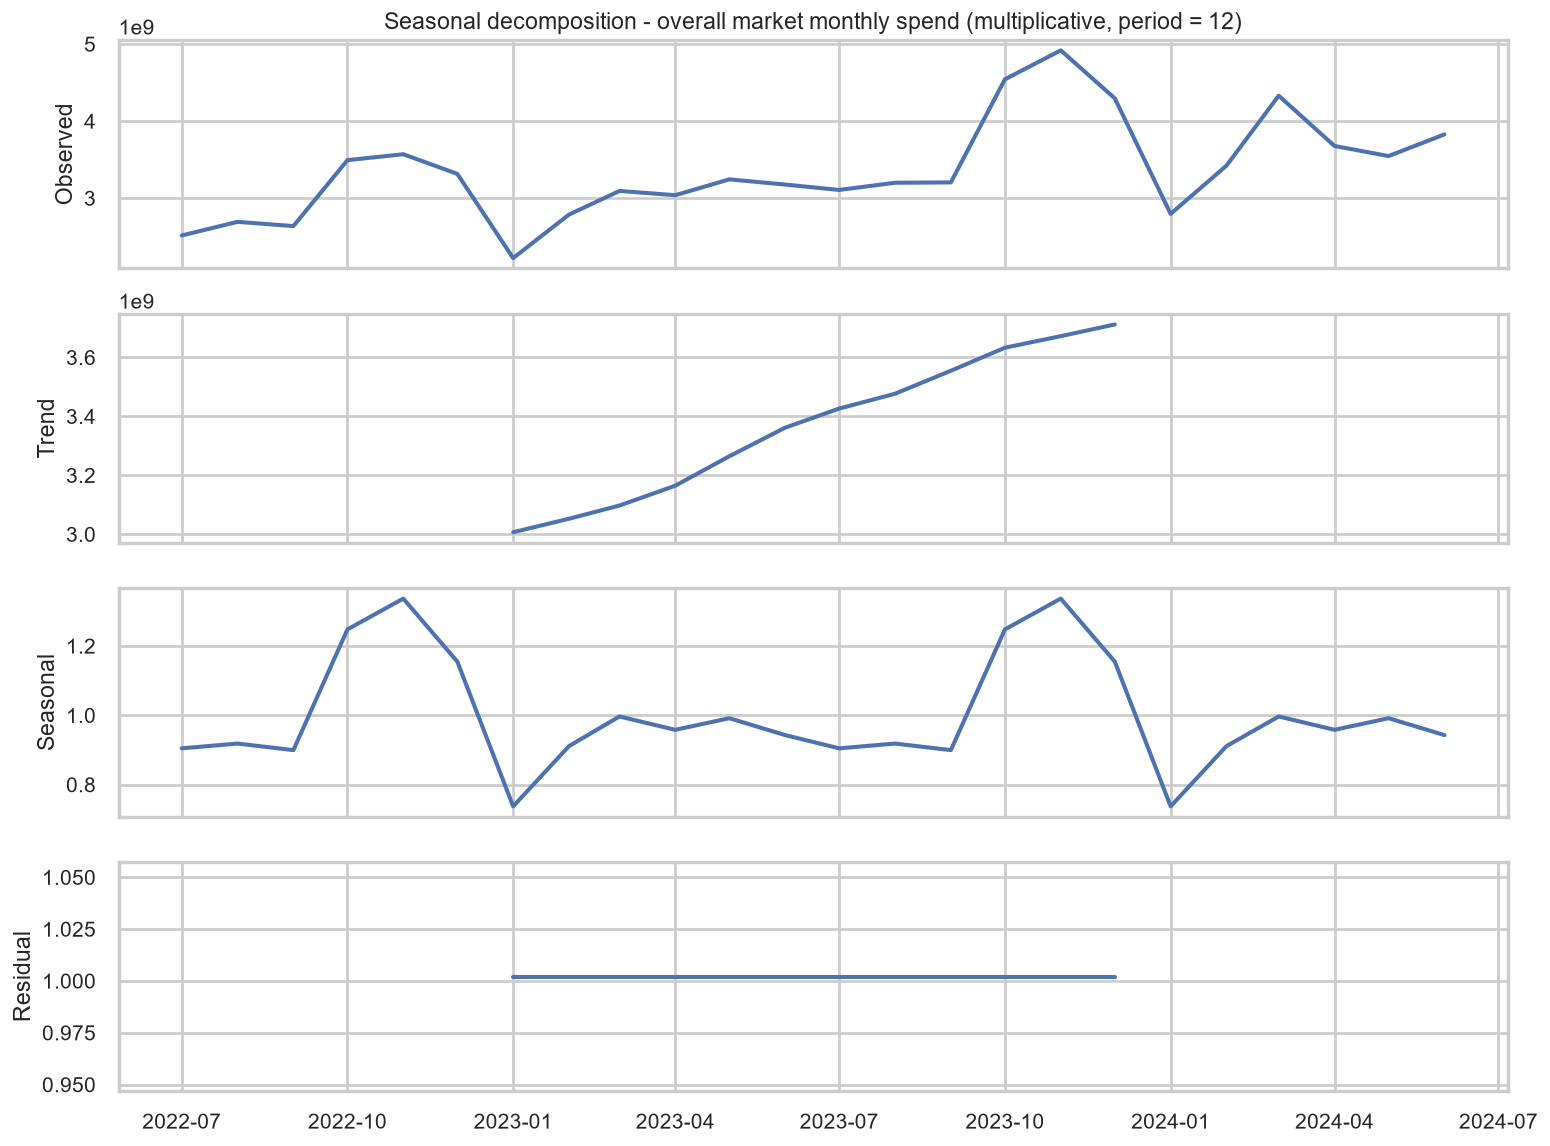

In [3]:
display(Image(FIG / 'ts_seasonality_decomposition.png', width=900))

## Model selection
Grid search over (p,d,q) in {0,1,2}x{0,1}x{0,1,2} and, for SARIMA, (P,D,Q,12) in {0,1}^3. Models are fit on log(spend) with a drift term; selection uses the small-sample corrected AICc. Holdout = last 3 months.

In [4]:
results, metrics = evaluate_forecasts(series)
metrics.round(4)

04:53:45 | INFO    | cred.time_series | cluster_0  ARIMA(0, 0, 1) MAPE=8.2% | SARIMA(0, 1, 1)(1, 0, 0, 12) MAPE=9.3%


04:54:38 | INFO    | cred.time_series | cluster_1  ARIMA(0, 0, 1) MAPE=8.9% | SARIMA(0, 1, 1)(1, 0, 0, 12) MAPE=9.1%


04:55:32 | INFO    | cred.time_series | cluster_2  ARIMA(0, 0, 1) MAPE=9.0% | SARIMA(0, 1, 1)(1, 0, 0, 12) MAPE=9.1%


04:56:24 | INFO    | cred.time_series | cluster_3  ARIMA(0, 0, 1) MAPE=8.5% | SARIMA(0, 1, 1)(1, 0, 0, 12) MAPE=9.5%


04:57:18 | INFO    | cred.time_series | cluster_4  ARIMA(0, 0, 1) MAPE=9.3% | SARIMA(0, 1, 1)(1, 0, 0, 12) MAPE=9.0%


04:58:10 | INFO    | cred.time_series | cluster_5  ARIMA(0, 0, 1) MAPE=8.6% | SARIMA(0, 1, 1)(1, 0, 0, 12) MAPE=9.7%


04:59:04 | INFO    | cred.time_series | Overall    ARIMA(0, 0, 1) MAPE=8.6% | SARIMA(0, 1, 1)(1, 0, 0, 12) MAPE=9.2%


,series,model,order,seasonal_order,aic,mape,rmse,mae
0,cluster_0,ARIMA,"(0, 0, 1)","(0, 0, 0, 0)",-6.5,0.0825,8.950039e+07,7.528541e+07
1,cluster_0,SARIMA,"(0, 1, 1)","(1, 0, 0, 12)",-23.2,0.0933,9.344300e+07,8.311558e+07
2,cluster_1,ARIMA,"(0, 0, 1)","(0, 0, 0, 0)",-8.9,0.0890,2.277425e+07,1.922491e+07
3,cluster_1,SARIMA,"(0, 1, 1)","(1, 0, 0, 12)",-25.4,0.0914,2.191355e+07,1.922131e+07
4,cluster_2,ARIMA,"(0, 0, 1)","(0, 0, 0, 0)",-8.5,0.0896,1.924073e+07,1.629104e+07
5,cluster_2,SARIMA,"(0, 1, 1)","(1, 0, 0, 12)",-24.7,0.0908,1.842559e+07,1.603068e+07
6,cluster_3,ARIMA,"(0, 0, 1)","(0, 0, 0, 0)",-7.0,0.0847,3.504262e+07,2.949606e+07
7,cluster_3,SARIMA,"(0, 1, 1)","(1, 0, 0, 12)",-23.7,0.0955,3.550398e+07,3.257461e+07
8,cluster_4,ARIMA,"(0, 0, 1)","(0, 0, 0, 0)",-9.9,0.0934,3.473365e+06,2.960242e+06
9,cluster_4,SARIMA,"(0, 1, 1)","(1, 0, 0, 12)",-26.0,0.0904,3.222294e+06,2.782254e+06


In [5]:
summarise(metrics)

{'sarima_mape_overall': 0.09202719037743366,
 'arima_mape_overall': 0.0855891883764049,
 'sarima_mape_cluster_avg': 0.0931246621300809,
 'arima_mape_cluster_avg': 0.08758228883544929,
 'sarima_advantage_pp': -0.6438002001028759}

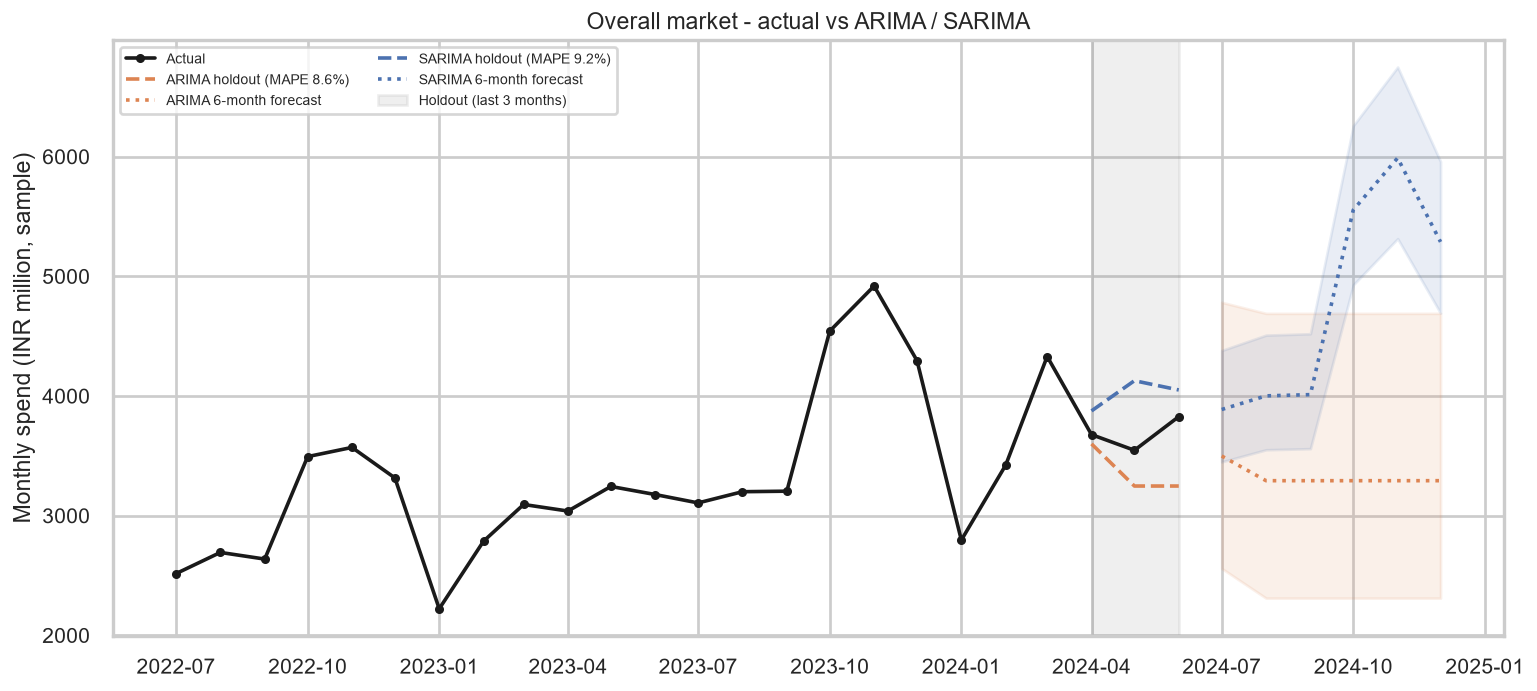

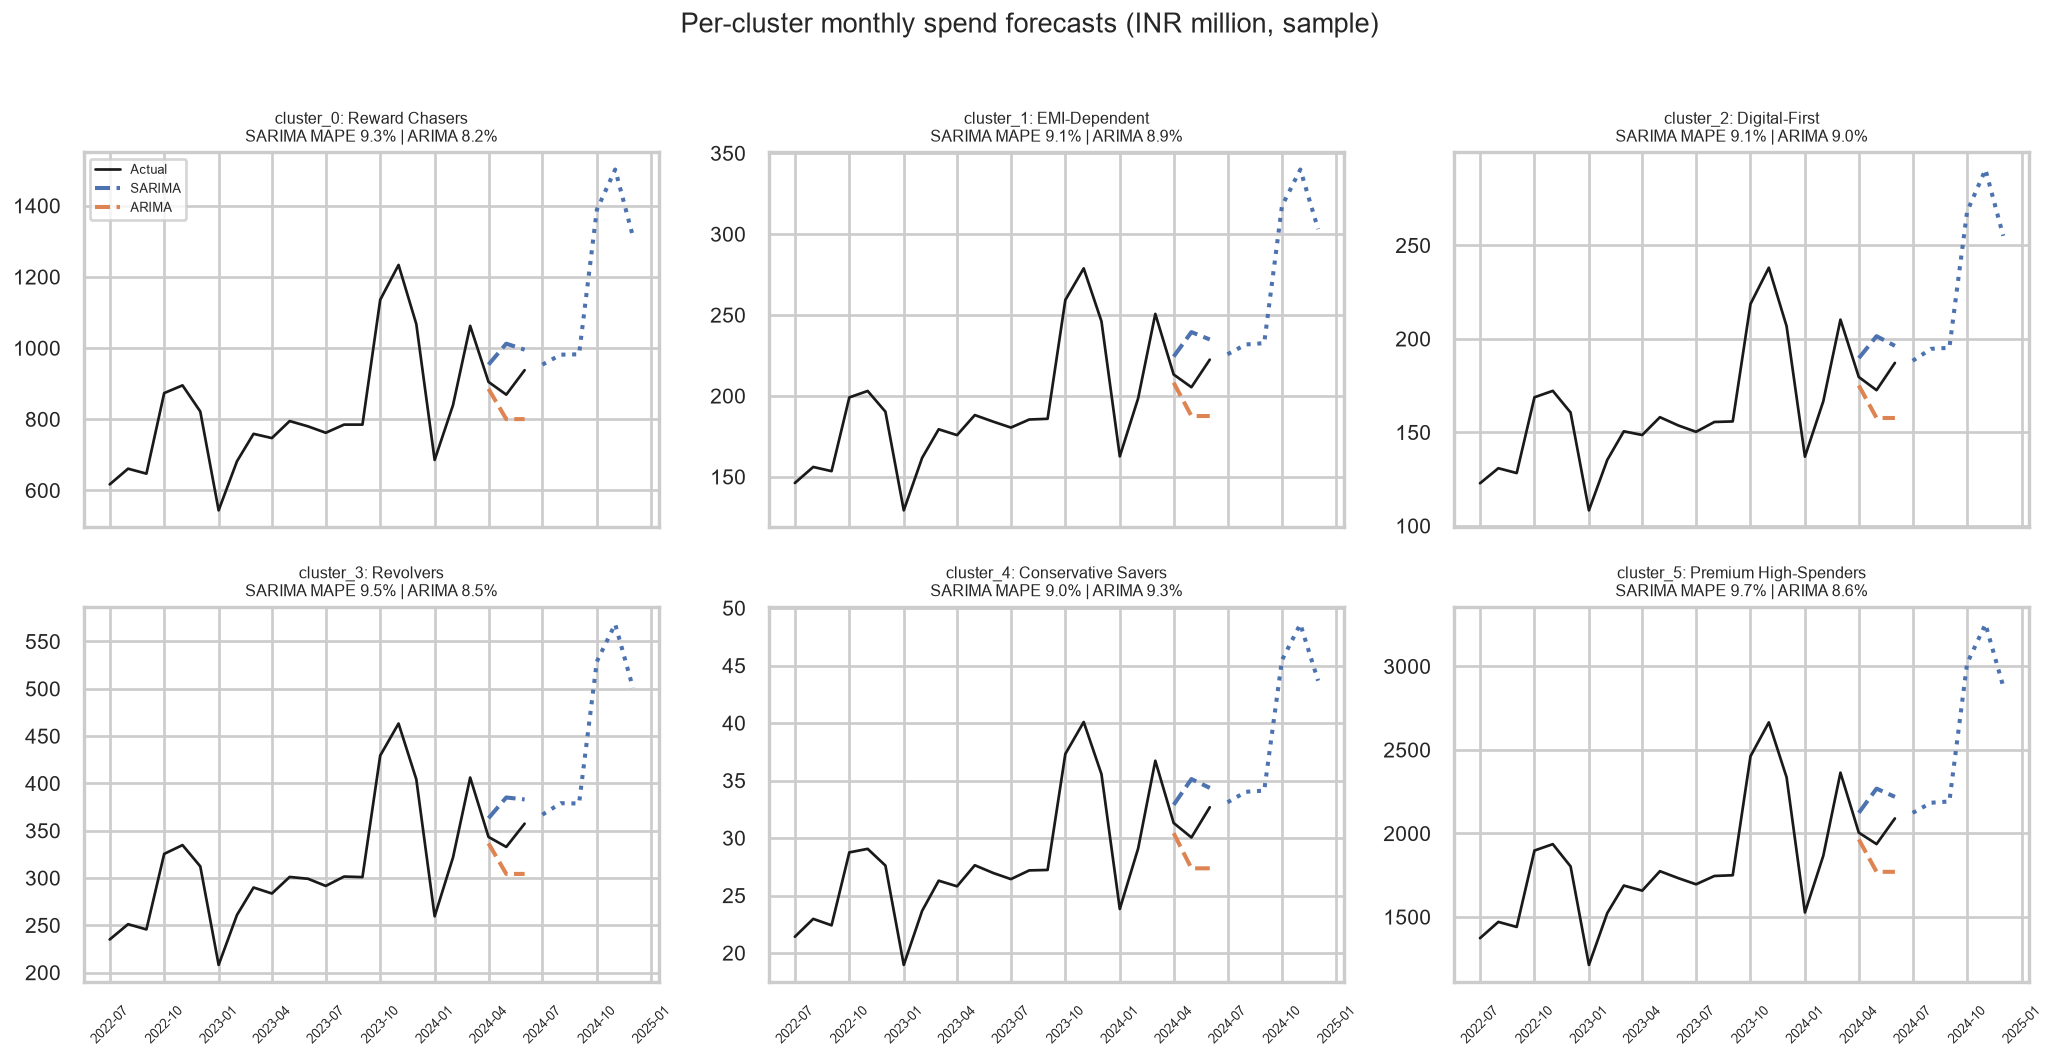

In [6]:
display(Image(FIG / 'ts_overall_forecast.png', width=1000)); display(Image(FIG / 'ts_per_cluster_forecast.png', width=1100))

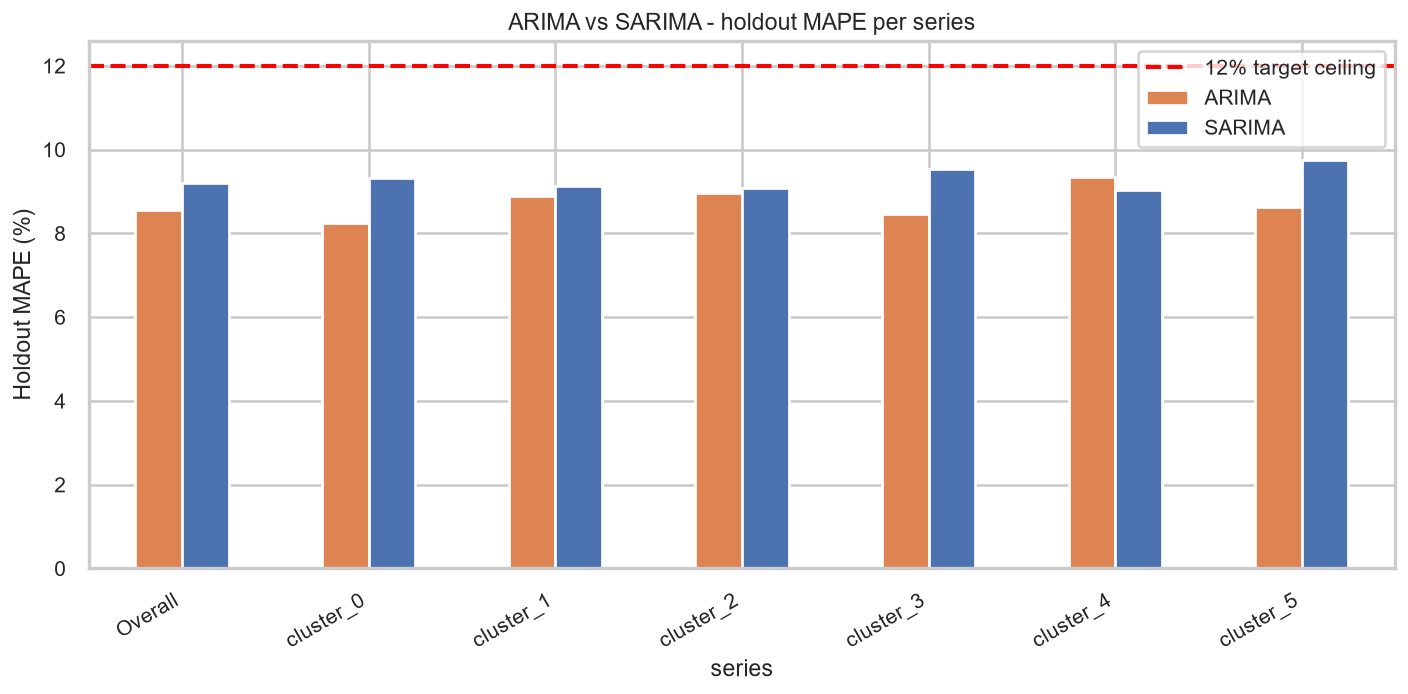

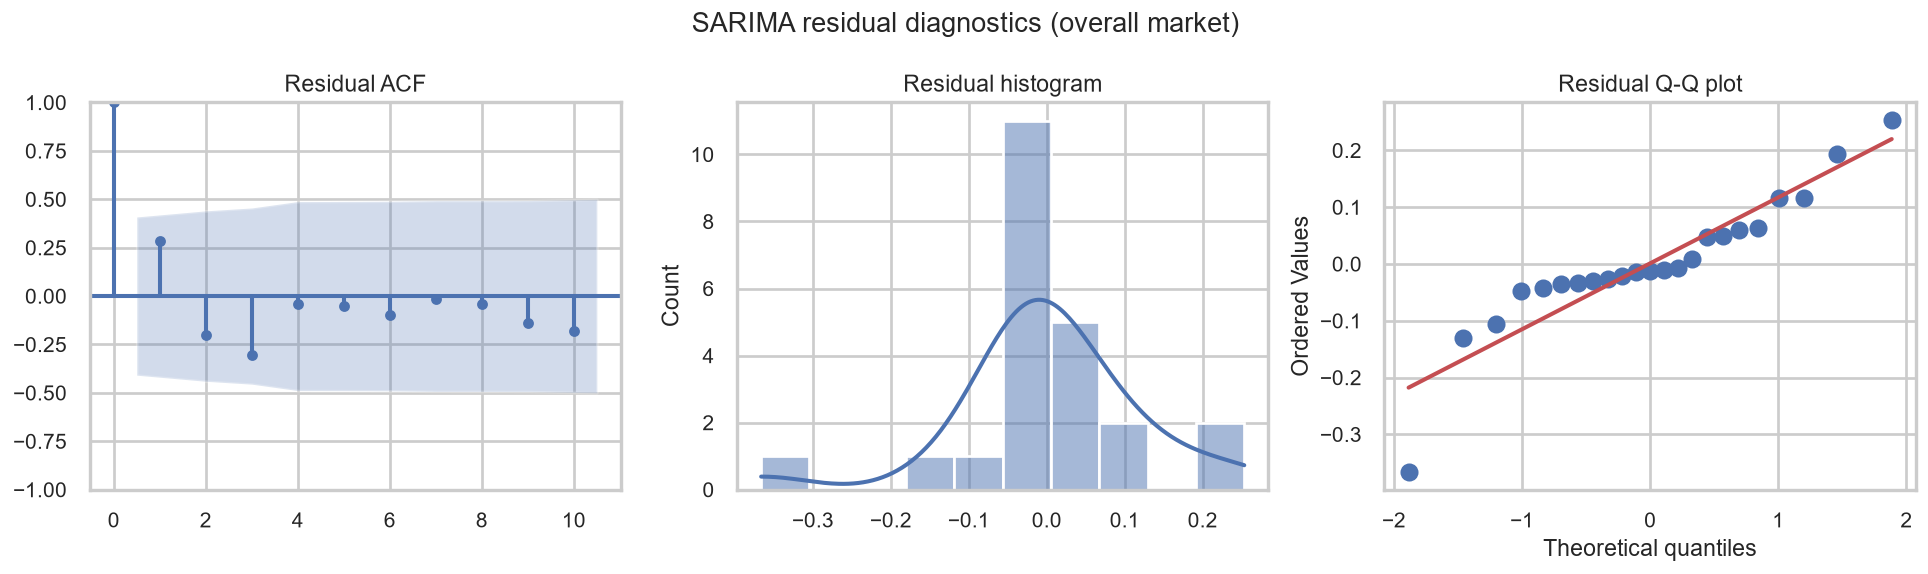

In [7]:
display(Image(FIG / 'ts_arima_vs_sarima.png', width=900)); display(Image(FIG / 'ts_residuals.png', width=1100))